# 한국 지역별(시도/시군구) HS 수출 수집 · 예측 · 기업 매출 연동 — v3

전국 HS 수출 대신 **기업 소재 지역의 HS 수출**로 기업 매출을 추정하기 위한 파이프라인입니다.
입력은 `(ticker, 기업명, HS코드, 시도[, 시군구])` 한 줄이면 됩니다. 예: `("A080220", "제주반도체", "854232", "제주")`

| PART | 내용 | 산출 |
|---|---|---|
| 1 | 환경 · Control Panel | |
| 2 | 시도코드 사전, 관세청 API 호출/파싱, `probe_api()` | |
| 3 | 응답 표준화 → 월별 long, DB 업서트, 증분 수집, 시계열 로드 | `korea_regional_trade_data` |
| 4 | SARIMA/ETS/Theta + median 앙상블 예측 (무실적 월이 많으면 분기 예측) | `korea_regional_trade_forecast` (forecast_date vintage 보존) |
| 5 | 기업-지역-HS 매핑 저장 | `korea_company_region_hscode_map` |
| 6 | 매출 실적/시계열예측 로드, 연동성 검정, 수출함의 매출(M1 비율법, M2 탄력성) | |
| 7 | 실행 (probe → 수집 → 예측 → 분석 → Excel) | `한국_지역별수출분석/YYYYMM/regional_export_revenue_YYYYMMDD.xlsx` |

### v2 → v3 변경
| # | 항목 | 내용 |
|---|---|---|
| 1 | **12개월 초과 기간 자동 분할** | API는 조회기간이 12개월을 넘으면 데이터를 반환하지 않음. `fetch_window()`가 요청 기간을 12개월 이하 구간으로 자동 분할·순차 호출 후 결합하도록 변경 → `probe_api`, 스캔 셀, 수집 파이프라인 등 **어디서 호출해도** 기간 제한 없음 (예: 201701~202608 → 10개 구간) |
| 2 | **구간별 로그** | 구간마다 resultCode/행수를 기록, 비정상 구간은 경고 출력 및 Collect_Log에 남김 |
| 3 | **단일 요청 가드** | 내부 함수 `_fetch_single_window()`에 12개월 초과 요청이 들어오면 즉시 오류 (조용한 누락 방지) |

### v1 → v2 변경
| # | 항목 | 내용 |
|---|---|---|
| 1 | **금액 단위 보정** | API 금액(`expUsdAmt` 등)은 **천 달러** 단위로 확인됨(제주 2026.1~8 반도체 합계 471,191 ≈ 뉴스 4.7억 달러). `API_AMOUNT_UNIT = 1000`으로 달러 환산해 전국 테이블(달러)과 단위 통일 |
| 2 | **복수 HS 입력** | `"854239+854231"`처럼 입력하면 HS별 개별 분석 + 합산 시계열(재예측) 분석을 함께 산출 |
| 3 | **HS 자릿수** | API는 6자리만 지원(2/4자리 요청은 resultCode 99) → 입력 검증에 반영 |
| 4 | **응답 필드 확정** | `priodTitle`, `sggNm`, `hsSgn`, `expUsdAmt`, `impUsdAmt`, `expCnt`, `impCnt`, `cmtrBlncAmt` — 요청 파라미터명(`strtYymm/endYymm/sidoCd/hsSgn`)도 정상 확인 |

> **v1으로 이미 수집을 실행했다면**: DB에 천 달러 단위 값이 들어가 있습니다. v2에서 `INCREMENTAL = False`로 **한 번 전체 재수집**하면 같은 키가 달러 단위로 덮어써집니다. 이후 `True`로 되돌리세요.

### 반드시 먼저 확인할 것
1. API 파라미터·필드는 probe로 검증 완료(v2). 응답 형식이 바뀌면 `API_PARAM_NAMES`(PART 1-2) / `FIELD_CANDIDATES`(PART 3-1)만 수정하세요.
2. **광주·전남 통합**: 2026-07부터 시도코드 12(전남광주통합특별시). 29(광주)·46(전남)은 2026-06까지만 존재합니다. 해당 지역 기업은 **'12'로 입력**하면 29+46 합산 → 12로 이어 붙인 연속 시계열이 자동 생성됩니다.
3. **지역 귀속 기준**: 지역별 무역통계는 일반적으로 수출 화주(신고자)의 사업장 소재지 기준으로 집계됩니다. 생산공장이 아닌 본사·수출법인 주소로 잡힐 수 있으니, 매핑 지역은 **실제 수출신고 주체의 소재지**로 넣는 것이 정확합니다.
4. 수집 데이터는 `ON DUPLICATE KEY UPDATE`로 저장합니다. 최근 `REVISION_MONTHS`개월은 매번 재수집해 확정치 수정분을 반영합니다(기존 전국 수집기의 '신규 키만 추가' 방식과 다름).

### 결과 해석 (Summary 시트)
- `grade`: 지역수출-매출 연동성 A(검증)/B(약함)/C(무효). A = HAC p<0.05, β>0, 표본외 RMSE < naive, Pearson-Spearman 괴리 ≤0.3, 점유율 드리프트 없음
- `g_rev_TS_12`: 기존 매출 시계열 예측(수출 정보 미사용) 기준 향후 4분기 성장률
- `g_rev_M1_ratio_12`: 최근 4분기 (매출 ÷ 원화환산 지역수출) 비율 × 미래 지역수출 — `ratio_cv_8q`가 낮을수록 신뢰
- `g_rev_M2_elastic_12`: YoY 탄력성(β, 최적 lag) 적용 — 등급 A/B일 때만 산출
- `region_share_of_national_12m`: 해당 지역이 전국 동일 HS 수출에서 차지하는 비중


## PART 1. 환경 · Control Panel

In [1]:
# =============================================================================
# PART 1-1. 환경 설정 (노트북 / 데스크탑 공용 경로)
# =============================================================================
import os
import re
import sys
import gc
import time
import math
import logging
import warnings
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Dict, Tuple, Union

import numpy as np
import pandas as pd
import requests
import xmltodict
from requests.adapters import HTTPAdapter
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")

# pandas 버전별 월말/분기말 alias (2.2+: 'ME'/'QE', 이전: 'M'/'Q')
try:
    pd.date_range("2020-01-31", periods=1, freq="ME")
    FREQ_M, FREQ_Q = "ME", "QE"
except Exception:
    FREQ_M, FREQ_Q = "M", "Q"
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("regional_trade")

KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",          # 데스크탑
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",  # 노트북
]


def setup_universal_paths() -> str:
    """DATA 폴더 자동 탐색 + 고정 경로 fallback. 프로젝트 루트와 DATA를 모두 sys.path에 추가."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로] 프로젝트 루트: {parent} | DATA: {data_folder}")
            return str(data_folder)
    for dp in KNOWN_DATA_PATHS:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로] 고정 경로 사용 | DATA: {dp}")
            return dp
    raise FileNotFoundError(f"DATA 폴더를 찾을 수 없습니다. 현재 위치: {current}")


DATA_PATH = setup_universal_paths()

from DATA.stock_invest_function import get_db_host  # noqa: E402

# 예측 모듈 (DATA 폴더의 universal_ts_forecast_function_v3.py) — 공유 모듈은 수정하지 않고 import만 한다
FORECAST_MODULE = "universal_ts_forecast_function_v3"
import importlib  # noqa: E402
_fc_mod = importlib.import_module(FORECAST_MODULE)
forecast_sarima = _fc_mod.forecast_sarima
forecast_ets = _fc_mod.forecast_ets
forecast_theta = _fc_mod.forecast_theta
print(f"[모듈] {FORECAST_MODULE} import 완료")

DB_INFO = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}


def make_engine(db_info: dict):
    url = (f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
           f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4")
    return create_engine(url, pool_pre_ping=True, pool_recycle=1800,
                         connect_args={"connect_timeout": 10, "read_timeout": 120, "write_timeout": 120})


engine = make_engine(DB_INFO)
print("[DB] engine 준비 완료")


[경로] 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy | DATA: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
[모듈] universal_ts_forecast_function_v3 import 완료
[DB] engine 준비 완료


In [2]:
# =============================================================================
# PART 1-2. Control Panel  —  사용자 입력은 여기 한 곳만 수정
# =============================================================================

# ---- (1) 분석 대상: (ticker, 기업명, HS코드, 시도[, 시군구]) ----
#   - 시도: 이름('제주', '제주도', '경기', '충북'...) 또는 코드('50') 모두 허용
#   - HS: 6자리만 지원 (API가 2/4자리 요청에 resultCode 99 반환). 여러 개는 '854239+854231'
#   - 시군구(선택): 이름('구미시')을 넣으면 해당 시군구 단위 시계열로 분석 (API가 시군구를 반환할 때만)
COMPANY_REGION_INPUTS = [
    ("A080220", "제주반도체", "854239+854231", "제주"),   # HS를 '+'로 묶으면 개별 + 합산 분석
    # ("A178920", "PI첨단소재", "392099", "경북", "구미시"),
]

# ---- (2) API ----
SERVICE_KEY = "2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D"
API_URL = "https://apis.data.go.kr/1220000/sigunguperprlstperacrs/getSigunguPerPrlstPerAcrs"

# 요청 파라미터 이름 (명세와 다르면 여기만 수정 — PART 2의 probe_api()로 먼저 확인)
API_PARAM_NAMES = {
    "start": "strtYymm",   # 조회 시작 YYYYMM
    "end":   "endYymm",    # 조회 종료 YYYYMM
    "sido":  "sidoCd",     # 시도코드
    "sgg":   "sggCd",      # 시군구코드 (미사용 시 요청에서 제외)
    "hs":    "hsSgn",      # 품목코드
    "imex":  "imexTpcd",   # 수출입구분 (1=수출, 2=수입) — None이면 요청에서 제외
    "page":  "pageNo",
    "rows":  "numOfRows",
}
API_IMEX_CODE      = None     # 수출만 받으려면 "1". 응답에 수출/수입이 같이 오면 None 유지
API_NUM_OF_ROWS    = 1000
API_AMOUNT_UNIT    = 1000     # 응답 금액(expUsdAmt/impUsdAmt/cmtrBlncAmt) 단위 = 천 달러 -> 달러로 환산하는 배수
                              # (probe 검증: 제주 2026.1~8 반도체 합계 471,191 = 뉴스 약 4.7억 달러)
                              # 전국 테이블 korea_monthly_trade_data 는 달러 단위이므로 반드시 맞춰야 함
MAX_WINDOW_MONTHS  = 12       # 1회 요청 최대 조회기간(개월)
RETRIES, TIMEOUT   = 3, 60
REQUEST_DELAY      = 0.15

# ---- (3) 수집 기간 ----
START_YYYYMM        = "201701"                             # 최초 수집 시작월
END_YYYYMM          = pd.Timestamp.today().strftime("%Y%m") # 최신월 (미발표 월은 빈 응답)
INCREMENTAL         = True    # True: DB 최신월 - REVISION_MONTHS 부터만 재수집
REVISION_MONTHS     = 3       # 최근 N개월은 확정치 수정 반영을 위해 재수집(덮어쓰기)
STORE_SGG_LEVEL     = True    # 시군구 단위 행도 DB에 저장

# ---- (4) 예측 ----
FORECAST_HORIZON_M  = 24      # 월 예측 기간
MIN_MONTHS          = 60      # 월 예측 최소 길이 (universal 모듈 기준과 동일)
MIN_QUARTERS        = 20      # 분기 fallback 최소 길이
MAX_ZERO_SHARE      = 0.20    # 0(무실적) 월 비중이 이보다 크면 월 예측 대신 분기 예측 시도
ENSEMBLE_AGG        = "median"
FORECAST_MODELS     = ["SARIMA", "ETS", "Theta"]

# ---- (5) 기업 매출 연동 ----
IMPLIED_HORIZON_Q   = 4       # 수출함의 매출 산출 분기 수 (기본 4분기)
LAGS                = [0, 1, 2]
MIN_YOY_OBS         = 16
OOS_START           = "2022Q1"
REV_VALUE_ABS_CAP   = 1e14    # 매출예측 SARIMA 발산 필터
RATIO_CV_WARN       = 0.30    # 매출/수출 비율 변동계수 경고 기준
FX_ADJUST           = True    # USD 수출을 원화로 환산 (FinanceDataReader USD/KRW)

# ---- (6) DB 테이블 ----
T_REGION_TRADE    = "korea_regional_trade_data"
T_REGION_FORECAST = "korea_regional_trade_forecast"
T_COMPANY_MAP     = "korea_company_region_hscode_map"
T_NATIONAL_TRADE  = "korea_monthly_trade_data"
T_FS              = "korea_fs_data_from_DG"
T_REV_FORECAST    = "korea_revenue_forecast_result"
DRY_RUN_DB        = False     # True면 DB 쓰기 없이 화면 출력만

# ---- (7) 결과 저장 폴더 ----
def _resolve_out_dir() -> Path:
    for base in [Path(r"C:\Users\82108\OneDrive\INVESTMENT"),
                 Path(r"C:\Users\Hoyoung_Park\OneDrive\INVESTMENT"),
                 Path.home() / "OneDrive" / "INVESTMENT"]:
        if base.exists():
            return base / "한국_지역별수출분석" / datetime.today().strftime("%Y%m")
    return Path.home() / "reports" / "regional_export"

OUT_DIR = Path(os.environ.get("REGION_EXPORT_OUT_DIR", str(_resolve_out_dir())))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"[설정] 대상 {len(COMPANY_REGION_INPUTS)}건 | 수집 {START_YYYYMM}~{END_YYYYMM} | 결과 폴더 {OUT_DIR}")


[설정] 대상 1건 | 수집 201701~202609 | 결과 폴더 C:\Users\82108\OneDrive\INVESTMENT\한국_지역별수출분석\202609


## PART 2. 시도코드 · 관세청 API

In [3]:
# =============================================================================
# PART 2-1. 시도코드 사전 (관세청조회코드_v1.3 '시도코드' 시트 기준)
# =============================================================================
SIDO_CODES = {
    "11": "서울특별시", "12": "전남광주통합특별시", "26": "부산광역시", "27": "대구광역시",
    "28": "인천광역시", "29": "광주광역시", "30": "대전광역시", "31": "울산광역시",
    "36": "세종특별자치시", "41": "경기도", "43": "충청북도", "44": "충청남도",
    "46": "전라남도", "47": "경상북도", "48": "경상남도", "50": "제주특별자치도",
    "51": "강원특별자치도", "52": "전북특별자치도",
}

# 약칭 -> 코드
SIDO_ALIASES = {
    "서울": "11", "부산": "26", "대구": "27", "인천": "28", "광주": "29", "대전": "30", "울산": "31",
    "세종": "36", "경기": "41", "충북": "43", "충청북": "43", "충남": "44", "충청남": "44",
    "전남": "46", "전라남": "46", "경북": "47", "경상북": "47", "경남": "48", "경상남": "48",
    "제주": "50", "제주도": "50", "강원": "51", "강원도": "51", "전북": "52", "전라북": "52",
    "전남광주": "12", "전남광주통합": "12",
}

# 행정구역 통합: 2026.7.1.부터 광주(29)+전남(46) -> 전남광주통합특별시(12)
#   '12'로 분석하면 2026-06까지는 29+46 합산, 2026-07부터는 12를 이어 붙여 연속 시계열을 만든다.
REGION_COMPOSITES = {
    "12": {"before_codes": ["29", "46"], "switch_yymm": "202607"},
}
DISCONTINUED_CODES = {"29": "202607", "46": "202607"}   # 이 월부터 코드 사용 중단


def resolve_sido(x) -> str:
    """'제주', '제주도', '제주특별자치도', 50, '50' -> '50'"""
    s = str(x).strip()
    if s.isdigit():
        s = s.zfill(2)
        if s in SIDO_CODES:
            return s
        raise ValueError(f"알 수 없는 시도코드: {x}")
    for code, name in SIDO_CODES.items():
        if s == name:
            return code
    if s in SIDO_ALIASES:
        return SIDO_ALIASES[s]
    for alias in sorted(SIDO_ALIASES, key=len, reverse=True):
        if s.startswith(alias):
            return SIDO_ALIASES[alias]
    raise ValueError(f"시도명을 해석할 수 없습니다: {x}")


def normalize_hs(x) -> Optional[str]:
    """HS 코드 문자열 정규화 (숫자형 저장으로 소실된 선행 0 복원). 2/4/6/8/10자리 허용."""
    if x is None:
        return None
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0+", s):
        s = s.split(".")[0]
    s = re.sub(r"\D", "", s)
    if not s:
        return None
    if len(s) % 2 == 1:
        s = "0" + s
    return s if len(s) in (2, 4, 6, 8, 10) else None


def normalize_ticker_a(t) -> Optional[str]:
    s = str(t).strip().upper()
    if len(s) == 7 and s.startswith("A"):
        s = s[1:]
    if s.isdigit():
        s = s.zfill(6)
    return "A" + s if re.fullmatch(r"[0-9A-Z]{6}", s) else None


# =============================================================================
# PART 2-2. 관세청 API 호출 / 파싱
# =============================================================================
def norm_yymm(yymm) -> str:
    s = str(yymm).strip()
    if not re.fullmatch(r"\d{6}", s) or not (1 <= int(s[4:]) <= 12):
        raise ValueError(f"YYYYMM 형식 오류: {yymm}")
    return s


def yymm_to_int(y: str) -> int:
    y = norm_yymm(y)
    return int(y[:4]) * 12 + int(y[4:]) - 1


def int_to_yymm(m: int) -> str:
    return f"{m // 12:04d}{m % 12 + 1:02d}"


def split_windows(start: str, end: str, max_months: int = MAX_WINDOW_MONTHS) -> List[Tuple[str, str]]:
    s, e = yymm_to_int(start), yymm_to_int(end)
    if e < s:
        return []
    out, cur = [], s
    while cur <= e:
        we = min(cur + max_months - 1, e)
        out.append((int_to_yymm(cur), int_to_yymm(we)))
        cur = we + 1
    return out


def make_session(pool: int = 4) -> requests.Session:
    sess = requests.Session()
    ad = HTTPAdapter(pool_connections=pool, pool_maxsize=pool)
    sess.mount("https://", ad)
    sess.mount("http://", ad)
    return sess


def _parse_response(xml_text: str) -> Tuple[pd.DataFrame, Dict]:
    """XML -> (items DataFrame, meta{resultCode, resultMsg, totalCount})"""
    meta = {"resultCode": None, "resultMsg": None, "totalCount": None}
    try:
        parsed = xmltodict.parse(xml_text)
    except Exception:
        meta["resultMsg"] = f"XML 파싱 실패: {xml_text[:200]}"
        return pd.DataFrame(), meta
    root = parsed.get("response") if isinstance(parsed, dict) else None
    if not isinstance(root, dict):
        # 공공데이터포털 인증 오류는 OpenAPI_ServiceResponse 형태로 온다
        err = parsed.get("OpenAPI_ServiceResponse", {}) if isinstance(parsed, dict) else {}
        hdr = err.get("cmmMsgHeader", {}) if isinstance(err, dict) else {}
        meta["resultCode"] = hdr.get("returnReasonCode")
        meta["resultMsg"] = hdr.get("returnAuthMsg") or hdr.get("errMsg") or str(parsed)[:200]
        return pd.DataFrame(), meta
    hdr = root.get("header") or {}
    if isinstance(hdr, dict):
        meta["resultCode"], meta["resultMsg"] = hdr.get("resultCode"), hdr.get("resultMsg")
    body = root.get("body") or {}
    if not isinstance(body, dict):
        return pd.DataFrame(), meta
    meta["totalCount"] = body.get("totalCount")
    items = body.get("items")
    item = items.get("item") if isinstance(items, dict) else None
    if item is None:
        return pd.DataFrame(), meta
    if isinstance(item, dict):
        item = [item]
    return pd.DataFrame(item), meta


def build_url(start: str, end: str, sido_cd: str, hs: str,
              sgg_cd: Optional[str] = None, page: int = 1) -> str:
    """serviceKey는 포털이 준 Encoding 키를 그대로 붙인다(requests params 사용 시 이중 인코딩 위험)."""
    p = API_PARAM_NAMES
    parts = [f"serviceKey={SERVICE_KEY}",
             f"{p['start']}={start}", f"{p['end']}={end}",
             f"{p['sido']}={sido_cd}", f"{p['hs']}={hs}"]
    if sgg_cd and p.get("sgg"):
        parts.append(f"{p['sgg']}={sgg_cd}")
    if API_IMEX_CODE and p.get("imex"):
        parts.append(f"{p['imex']}={API_IMEX_CODE}")
    if p.get("page"):
        parts.append(f"{p['page']}={page}")
    if p.get("rows"):
        parts.append(f"{p['rows']}={API_NUM_OF_ROWS}")
    return API_URL + "?" + "&".join(parts)


def fetch_window(session: requests.Session, start: str, end: str, sido_cd: str, hs: str,
                 sgg_cd: Optional[str] = None) -> Tuple[pd.DataFrame, Dict]:
    """기간 제한 없는 수집 진입점.
    API는 조회기간이 12개월을 넘으면 데이터를 주지 않으므로, 요청 기간을 MAX_WINDOW_MONTHS 이하
    구간으로 자동 분할해 순차 호출한 뒤 합친다. (probe_api, 스캔 셀 등 어디서 호출해도 안전)
    반환 meta: 첫 비정상 구간의 resultCode/resultMsg(모두 정상이면 '00'), 구간별 로그 windows
    """
    start, end = norm_yymm(start), norm_yymm(end)
    wins = split_windows(start, end)
    if not wins:
        raise ValueError(f"종료월이 시작월보다 빠릅니다: {start} ~ {end}")
    frames, logs = [], []
    for ws, we in wins:
        df, m = _fetch_single_window(session, ws, we, sido_cd, hs, sgg_cd)
        logs.append({"win": f"{ws}-{we}", "rows": len(df), "resultCode": m.get("resultCode"),
                     "resultMsg": m.get("resultMsg"), "totalCount": m.get("totalCount")})
        if not df.empty:
            frames.append(df)
    bad = [l for l in logs if str(l["resultCode"]) not in ("00", "0", "None")]
    meta = {"resultCode": bad[0]["resultCode"] if bad else "00",
            "resultMsg": bad[0]["resultMsg"] if bad else "정상서비스",
            "totalCount": sum(int(l["totalCount"] or 0) for l in logs
                              if str(l["totalCount"] or "0").isdigit()),
            "n_windows": len(wins), "windows": logs}
    if bad:
        logger.warning(f"[수집] {sido_cd}/{hs} 비정상 구간 {len(bad)}/{len(wins)}: "
                       f"{[(b['win'], b['resultCode'], b['resultMsg']) for b in bad]}")
    return (pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()), meta


def _fetch_single_window(session: requests.Session, start: str, end: str, sido_cd: str, hs: str,
                         sgg_cd: Optional[str] = None) -> Tuple[pd.DataFrame, Dict]:
    """단일 window(<= 12개월) 수집 (페이지 자동 순회, 재시도). 직접 호출하지 말고 fetch_window 사용."""
    if yymm_to_int(end) - yymm_to_int(start) + 1 > MAX_WINDOW_MONTHS:
        raise ValueError(f"단일 요청 기간 초과: {start}~{end} (> {MAX_WINDOW_MONTHS}개월)")
    frames, page, meta = [], 1, {}
    while True:
        url = build_url(start, end, sido_cd, hs, sgg_cd, page)
        df, meta = pd.DataFrame(), {"resultCode": None, "resultMsg": "no response", "totalCount": None}
        for attempt in range(RETRIES):
            try:
                r = session.get(url, timeout=TIMEOUT)
                if r.status_code in (429, 500, 502, 503, 504) and attempt < RETRIES - 1:
                    time.sleep(2 ** attempt)
                    continue
                r.raise_for_status()
                df, meta = _parse_response(r.text)
                break
            except requests.exceptions.RequestException as e:
                meta["resultMsg"] = str(e)
                if attempt < RETRIES - 1:
                    time.sleep(2 ** attempt)
        if REQUEST_DELAY:
            time.sleep(REQUEST_DELAY)
        if not df.empty:
            frames.append(df)
        try:
            total = int(meta.get("totalCount") or 0)
        except (TypeError, ValueError):
            total = 0
        if df.empty or total <= page * API_NUM_OF_ROWS:
            break
        page += 1
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if not out.empty:
        out["req_sido_cd"], out["req_hs"] = sido_cd, hs
        out["req_start"], out["req_end"] = start, end
    return out, meta


def probe_api(sido: str = "50", hs: str = "854239", start: str = "202501", end: str = "202608",
              show_rows: int = 10) -> pd.DataFrame:
    """[최초 1회 필수] 실제 응답 구조 확인 (HS는 6자리만 지원 — 2/4자리는 resultCode 99) — 필드명, 시군구 행/총계 행, HS 계층 여부를 눈으로 검증."""
    sido_cd = resolve_sido(sido)
    sess = make_session(1)
    df, meta = fetch_window(sess, norm_yymm(start), norm_yymm(end), sido_cd, hs)
    sess.close()
    masked = build_url(start, end, sido_cd, hs).replace(SERVICE_KEY, "***KEY***")
    print(f"[probe] {masked}")
    print(f"[probe] 요청 {start}~{end} -> {meta.get('n_windows')}개 구간으로 분할 호출")
    for w in meta.get("windows", []):
        print(f"   - {w['win']}: resultCode={w['resultCode']} rows={w['rows']} msg={w['resultMsg']}")
    print(f"[probe] 합계 rows={len(df)}")
    if df.empty:
        print("[probe] 응답 행이 없습니다. API_PARAM_NAMES / 인증키 / 기간을 확인하세요.")
        return df
    print("[probe] 응답 필드:", list(df.columns))
    for c in df.columns:
        if df[c].nunique() <= 30:
            print(f"   - {c}: {sorted(df[c].astype(str).unique().tolist())[:30]}")
    display(df.head(show_rows))
    return df


## PART 3. 표준화 · DB · 수집 · 로드

In [4]:
# =============================================================================
# PART 3-1. 응답 표준화 -> 시도/시군구 월별 long 데이터
# =============================================================================
FIELD_CANDIDATES = {
    "period":  ["year", "yymm", "statYymm", "priodTitle", "ym", "baseYymm"],
    "sido_cd": ["sidoCd", "sido_cd"],
    "sido_nm": ["sidoNm", "sidoName", "sido"],
    "sgg_cd":  ["sggCd", "sigunguCd", "sgguCd", "signguCd"],
    "sgg_nm":  ["sggNm", "sigunguNm", "sgguNm", "signguNm", "sigungu"],
    "hs_row":  ["hsCd", "hsCode", "hsSgn", "prlstCd"],
    "hs_nm":   ["statKor", "hsNm", "korePrlstNm", "prlstNm", "hsKorNm"],
    "expDlr":  ["expDlr", "expUsdAmt", "expAmt"],
    "expWgt":  ["expWgt", "expWght"],
    "expCnt":  ["expCnt", "expCascnt", "expCase"],
    "impDlr":  ["impDlr", "impUsdAmt", "impAmt"],
    "impWgt":  ["impWgt", "impWght"],
    "impCnt":  ["impCnt", "impCascnt", "impCase"],
    "balPayments": ["balPayments", "cmtrBlncAmt", "tradeBal"],
}
VALUE_FIELDS = ["expDlr", "expWgt", "expCnt", "impDlr", "impWgt", "impCnt", "balPayments"]
AMOUNT_FIELDS = {"expDlr", "impDlr", "balPayments"}   # API_AMOUNT_UNIT 배수를 적용할 금액 필드
TOTAL_TOKENS = {"", "전체", "합계", "소계", "총계", "계", "nan", "None", "-"}
SIDO_TOTAL_KEY = "00000"   # 시도 합계 행의 sgg_cd


def _pick_col(cols, cands) -> Optional[str]:
    low = {str(c).lower(): c for c in cols}
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None


def _period_to_date(v) -> pd.Timestamp:
    d = re.sub(r"\D", "", str(v))
    if len(d) >= 6 and 1 <= int(d[4:6]) <= 12:
        return pd.Timestamp(int(d[:4]), int(d[4:6]), 1) + pd.offsets.MonthEnd(0)
    return pd.NaT


def standardize_raw(raw: pd.DataFrame) -> pd.DataFrame:
    """API 원본 -> 표준 컬럼. 필드명이 달라도 FIELD_CANDIDATES로 자동 매칭."""
    if raw.empty:
        return pd.DataFrame()
    col = {k: _pick_col(raw.columns, v) for k, v in FIELD_CANDIDATES.items()}
    if col["period"] is None:
        raise KeyError(f"기간 필드를 찾지 못했습니다. 응답 필드: {list(raw.columns)} "
                       f"-> FIELD_CANDIDATES['period']에 추가하세요.")
    out = pd.DataFrame(index=raw.index)
    out["date"] = raw[col["period"]].map(_period_to_date)
    out["sido_cd"] = (raw[col["sido_cd"]].astype(str).str.strip() if col["sido_cd"]
                      else raw["req_sido_cd"].astype(str))
    out["sido_nm"] = raw[col["sido_nm"]].astype(str).str.strip() if col["sido_nm"] else ""
    sgg_cd = raw[col["sgg_cd"]].astype(str).str.strip() if col["sgg_cd"] else pd.Series("", index=raw.index)
    sgg_nm = raw[col["sgg_nm"]].astype(str).str.strip() if col["sgg_nm"] else pd.Series("", index=raw.index)
    out["sgg_nm"] = sgg_nm.where(~sgg_nm.isin(["nan", "None"]), "")
    out["sgg_cd"] = sgg_cd.where(~sgg_cd.isin(["", "nan", "None"]), out["sgg_nm"])
    out["hs_row"] = (raw[col["hs_row"]].map(lambda x: re.sub(r"\D", "", str(x))) if col["hs_row"]
                     else raw["req_hs"].astype(str))
    out["hs_nm"] = raw[col["hs_nm"]].astype(str) if col["hs_nm"] else ""
    for f in VALUE_FIELDS:
        c = col.get(f)
        out[f] = pd.to_numeric(raw[c].astype(str).str.replace(",", ""), errors="coerce") if c else np.nan
        if f in AMOUNT_FIELDS:
            out[f] = out[f] * API_AMOUNT_UNIT       # 천 달러 -> 달러
    out["req_sido_cd"], out["req_hs"] = raw["req_sido_cd"].astype(str), raw["req_hs"].astype(str)
    out = out.dropna(subset=["date"])       # '총계' 등 기간이 아닌 행 제거
    return out.reset_index(drop=True)


def _select_hs_level(df: pd.DataFrame, req_hs: str) -> Tuple[pd.DataFrame, str]:
    """HS 계층 중복 합산 방지: 요청코드와 같은 행이 있으면 그 행만, 없으면 가장 상위(짧은) 레벨만 사용."""
    if df["hs_row"].eq("").all():
        return df, "no_hs_field"
    if df["hs_row"].eq(req_hs).any():
        return df[df["hs_row"] == req_hs], "exact"
    sub = df[df["hs_row"].str.startswith(req_hs)]
    if sub.empty:
        return df, "unmatched"     # 응답 코드 체계가 다르면 전체 사용 (probe로 확인 필요)
    min_len = sub["hs_row"].str.len().min()
    return sub[sub["hs_row"].str.len() == min_len], f"children_len{min_len}"


def aggregate_region(std: pd.DataFrame, req_hs: str) -> Tuple[pd.DataFrame, Dict]:
    """표준화 데이터 -> long(date, sido_cd, sgg_cd, sgg_nm, sido_nm, hs_code, indicator, value)
    - 시군구 행과 시도 합계 행이 섞여 오면 합계 행 우선, 없으면 시군구 합산
    """
    diag = {"hs_level": None, "sido_total_source": None, "total_vs_sum_maxdiff": None}
    if std.empty:
        return pd.DataFrame(), diag
    frames = []
    for sido_cd, g in std.groupby("req_sido_cd"):
        g, diag["hs_level"] = _select_hs_level(g, req_hs)
        nm, cd = g["sgg_nm"], g["sgg_cd"]
        is_total = ((nm.isin(TOTAL_TOKENS) & (cd.isin(TOTAL_TOKENS | {SIDO_TOTAL_KEY})
                                               | cd.str.fullmatch(r"\d{2}000")))
                    | nm.isin({"합계", "소계", "총계", "전체", "계"}))
        sido_nm = next((n for n in g["sido_nm"] if n and n not in TOTAL_TOKENS), SIDO_CODES.get(sido_cd, ""))
        sgg_part = g[~is_total]
        tot_part = g[is_total]
        vals = [f for f in VALUE_FIELDS if g[f].notna().any()]

        sgg_m = (sgg_part.groupby(["date", "sgg_cd", "sgg_nm"])[vals].sum(min_count=1).reset_index()
                 if not sgg_part.empty else pd.DataFrame())
        if not tot_part.empty:
            sido_m = tot_part.groupby("date")[vals].sum(min_count=1).reset_index()
            diag["sido_total_source"] = "total_rows"
            if not sgg_m.empty and "expDlr" in vals:
                chk = sgg_m.groupby("date")["expDlr"].sum().to_frame("sgg_sum").join(
                    sido_m.set_index("date")["expDlr"].rename("tot"), how="inner")
                rel = (chk["sgg_sum"] - chk["tot"]).abs() / chk["tot"].replace(0, np.nan)
                diag["total_vs_sum_maxdiff"] = float(rel.max()) if len(rel.dropna()) else None
        elif not sgg_m.empty:
            sido_m = sgg_m.groupby("date")[vals].sum(min_count=1).reset_index()
            diag["sido_total_source"] = "sum_of_sgg"
        else:
            continue
        sido_m["sgg_cd"], sido_m["sgg_nm"] = SIDO_TOTAL_KEY, ""
        parts = [sido_m] + ([sgg_m] if (STORE_SGG_LEVEL and not sgg_m.empty) else [])
        m = pd.concat(parts, ignore_index=True)
        m["sido_cd"], m["sido_nm"], m["hs_code"] = sido_cd, sido_nm, req_hs
        frames.append(m.melt(id_vars=["date", "sido_cd", "sido_nm", "sgg_cd", "sgg_nm", "hs_code"],
                             value_vars=vals, var_name="indicator", value_name="value"))
    if not frames:
        return pd.DataFrame(), diag
    long_df = pd.concat(frames, ignore_index=True).dropna(subset=["value"])
    long_df["sgg_cd"] = long_df["sgg_cd"].astype(str).str.slice(0, 40)
    return long_df, diag


# =============================================================================
# PART 3-2. DB 테이블 (없으면 생성) / 업서트
# =============================================================================
DDL = {
    T_REGION_TRADE: f"""
        CREATE TABLE IF NOT EXISTS `{T_REGION_TRADE}` (
            `date` DATE NOT NULL,
            `sido_cd` VARCHAR(4) NOT NULL,
            `sgg_cd` VARCHAR(40) NOT NULL,
            `hs_code` VARCHAR(10) NOT NULL,
            `indicator` VARCHAR(30) NOT NULL,
            `value` DOUBLE NULL,
            `sido_nm` VARCHAR(40) NULL,
            `sgg_nm` VARCHAR(60) NULL,
            `updated_at` DATETIME DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
            PRIMARY KEY (`date`, `sido_cd`, `sgg_cd`, `hs_code`, `indicator`),
            KEY `idx_hs_sido` (`hs_code`, `sido_cd`)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci""",
    T_REGION_FORECAST: f"""
        CREATE TABLE IF NOT EXISTS `{T_REGION_FORECAST}` (
            `forecast_date` DATE NOT NULL,
            `date` DATE NOT NULL,
            `freq` CHAR(1) NOT NULL,
            `sido_cd` VARCHAR(4) NOT NULL,
            `sgg_cd` VARCHAR(40) NOT NULL,
            `hs_code` VARCHAR(10) NOT NULL,
            `indicator` VARCHAR(30) NOT NULL,
            `value` DOUBLE NULL,
            `last_actual` DATE NULL,
            `n_obs` INT NULL,
            `created_at` DATETIME DEFAULT CURRENT_TIMESTAMP,
            PRIMARY KEY (`forecast_date`, `date`, `freq`, `sido_cd`, `sgg_cd`, `hs_code`, `indicator`),
            KEY `idx_key` (`hs_code`, `sido_cd`, `sgg_cd`)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci""",
    T_COMPANY_MAP: f"""
        CREATE TABLE IF NOT EXISTS `{T_COMPANY_MAP}` (
            `ticker` VARCHAR(10) NOT NULL,
            `company_name` VARCHAR(100) NOT NULL,
            `hs_code` VARCHAR(10) NOT NULL,
            `sido_cd` VARCHAR(4) NOT NULL,
            `sgg_nm` VARCHAR(60) NOT NULL DEFAULT '',
            `sido_nm` VARCHAR(40) NULL,
            `is_active` TINYINT NOT NULL DEFAULT 1,
            `note` VARCHAR(200) NULL,
            `created_at` DATETIME DEFAULT CURRENT_TIMESTAMP,
            `updated_at` DATETIME DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
            PRIMARY KEY (`ticker`, `hs_code`, `sido_cd`, `sgg_nm`)
        ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci""",
}


def ensure_tables():
    if DRY_RUN_DB:
        print("[DRY_RUN] 테이블 생성 생략")
        return
    with engine.begin() as conn:
        for name, ddl in DDL.items():
            conn.execute(text(ddl))
    print(f"[DB] 테이블 확인/생성 완료: {list(DDL)}")


def upsert_rows(table: str, df: pd.DataFrame, key_cols: List[str], upd_cols: List[str],
                chunk: int = 2000) -> int:
    """INSERT ... ON DUPLICATE KEY UPDATE (확정치 수정분을 덮어쓴다)."""
    if df is None or df.empty:
        return 0
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.astype(object).where(pd.notnull(df), None)
    cols = key_cols + [c for c in upd_cols if c not in key_cols]
    sql = text(
        f"INSERT INTO `{table}` ({', '.join(f'`{c}`' for c in cols)}) "
        f"VALUES ({', '.join(f':{c}' for c in cols)}) "
        f"ON DUPLICATE KEY UPDATE {', '.join(f'`{c}`=VALUES(`{c}`)' for c in upd_cols)}"
    )
    rows = df[cols].to_dict("records")
    if DRY_RUN_DB:
        print(f"[DRY_RUN] {table}: {len(rows)}행 업서트 예정")
        return 0
    with engine.begin() as conn:
        for i in range(0, len(rows), chunk):
            conn.execute(sql, rows[i:i + chunk])
    return len(rows)


# =============================================================================
# PART 3-3. 수집 파이프라인 (지역 통합 코드 처리 + 증분 수집)
# =============================================================================
def plan_requests(target_sido: str, start: str, end: str) -> List[Tuple[str, str, str]]:
    """분석 대상 시도 -> 실제 API 요청 [(요청 시도코드, 시작, 종료)]"""
    s, e = yymm_to_int(start), yymm_to_int(end)
    plans = []
    if target_sido in REGION_COMPOSITES:
        comp = REGION_COMPOSITES[target_sido]
        sw = yymm_to_int(comp["switch_yymm"])
        if s < sw:
            for c in comp["before_codes"]:
                plans.append((c, start, int_to_yymm(min(e, sw - 1))))
        if e >= sw:
            plans.append((target_sido, int_to_yymm(max(s, sw)), end))
        return plans
    if target_sido in DISCONTINUED_CODES:
        stop = yymm_to_int(DISCONTINUED_CODES[target_sido])
        if e >= stop:
            logger.warning(f"시도코드 {target_sido}는 {DISCONTINUED_CODES[target_sido]}부터 사용 중단 "
                           f"-> 통합코드 '12' 사용을 권장합니다. 중단 이후 구간은 수집하지 않습니다.")
        if s < stop:
            plans.append((target_sido, start, int_to_yymm(min(e, stop - 1))))
        return plans
    return [(target_sido, start, end)]


def db_last_month(sido_codes: List[str], hs: str) -> Optional[pd.Timestamp]:
    q = text(f"SELECT MAX(`date`) AS d FROM `{T_REGION_TRADE}` "
             f"WHERE hs_code = :hs AND sgg_cd = :tk AND indicator = 'expDlr' AND sido_cd IN :codes")
    from sqlalchemy import bindparam
    q = q.bindparams(bindparam("codes", expanding=True))
    try:
        with engine.connect() as conn:
            d = pd.read_sql(q, conn, params={"hs": hs, "tk": SIDO_TOTAL_KEY, "codes": sido_codes})["d"].iloc[0]
        return pd.Timestamp(d) if pd.notna(d) else None
    except Exception:
        return None


def collect_region_hs(target_sido: str, hs: str, start: str = START_YYYYMM,
                      end: str = END_YYYYMM, incremental: bool = INCREMENTAL) -> Dict:
    """(시도, HS) 1건 수집 -> DB 업서트. 반환: 요약 dict"""
    hs = normalize_hs(hs)
    all_codes = ([target_sido] + REGION_COMPOSITES.get(target_sido, {}).get("before_codes", []))
    if incremental:
        last = db_last_month(all_codes, hs)
        if last is not None:
            inc_start = (last - pd.DateOffset(months=REVISION_MONTHS - 1)).strftime("%Y%m")
            start = max(start, inc_start)
    raws, metas = [], []
    sess = make_session(2)
    try:
        for req_cd, s, e in plan_requests(target_sido, start, end):
            df, meta = fetch_window(sess, s, e, req_cd, hs)      # 12개월 초과 기간은 내부에서 자동 분할
            for w in meta.get("windows", [meta]):
                metas.append({"sido": req_cd, **w})
            if not df.empty:
                raws.append(df)
    finally:
        sess.close()
    meta_df = pd.DataFrame(metas)
    if not raws:
        logger.warning(f"[수집] {target_sido}/{hs}: 응답 없음 {start}~{end}")
        return {"target": target_sido, "hs": hs, "rows_saved": 0, "meta": meta_df, "diag": {}}
    std = standardize_raw(pd.concat(raws, ignore_index=True))
    long_df, diag = aggregate_region(std, hs)
    long_df["date"] = pd.to_datetime(long_df["date"]).dt.date
    n = upsert_rows(T_REGION_TRADE, long_df,
                    key_cols=["date", "sido_cd", "sgg_cd", "hs_code", "indicator"],
                    upd_cols=["value", "sido_nm", "sgg_nm"])
    logger.info(f"[수집] {target_sido}/{hs} {start}~{end}: 원본 {len(std)}행 -> 저장 {n}행 | {diag}")
    return {"target": target_sido, "hs": hs, "rows_saved": n, "meta": meta_df, "diag": diag,
            "long": long_df}


# =============================================================================
# PART 3-4. 시계열 로드 (통합 코드 연결 + 무실적 월 0 채움)
# =============================================================================
def _published_last_month(sido_codes: List[str]) -> Optional[pd.Timestamp]:
    """해당 시도의 전체 HS 기준 최신 적재월 (그 달까지는 행이 없으면 0으로 간주)."""
    from sqlalchemy import bindparam
    q = text(f"SELECT MAX(`date`) AS d FROM `{T_REGION_TRADE}` WHERE sido_cd IN :codes") \
        .bindparams(bindparam("codes", expanding=True))
    with engine.connect() as conn:
        d = pd.read_sql(q, conn, params={"codes": sido_codes})["d"].iloc[0]
    return pd.Timestamp(d) + pd.offsets.MonthEnd(0) if pd.notna(d) else None


def load_region_series(target_sido: str, hs: str, sgg_nm: str = "",
                       indicator: str = "expDlr") -> pd.Series:
    """월말 인덱스 Series. sgg_nm=''이면 시도 합계, 값이 있으면 해당 시군구."""
    from sqlalchemy import bindparam
    hs = normalize_hs(hs)
    comp = REGION_COMPOSITES.get(target_sido)
    codes = [target_sido] + (comp["before_codes"] if comp else [])
    cond = "sgg_cd = :tk" if not sgg_nm else "sgg_nm = :sn"
    q = text(f"SELECT `date`, sido_cd, value FROM `{T_REGION_TRADE}` "
             f"WHERE hs_code = :hs AND indicator = :ind AND {cond} AND sido_cd IN :codes") \
        .bindparams(bindparam("codes", expanding=True))
    with engine.connect() as conn:
        df = pd.read_sql(q, conn, params={"hs": hs, "ind": indicator, "tk": SIDO_TOTAL_KEY,
                                          "sn": sgg_nm, "codes": codes})
    if df.empty:
        return pd.Series(dtype=float, name=f"{target_sido}_{hs}")
    df["date"] = pd.to_datetime(df["date"]) + pd.offsets.MonthEnd(0)
    if comp:
        sw = pd.Timestamp(comp["switch_yymm"][:4] + "-" + comp["switch_yymm"][4:] + "-01")
        df = df[((df["sido_cd"].isin(comp["before_codes"])) & (df["date"] < sw))
                | ((df["sido_cd"] == target_sido) & (df["date"] >= sw))]
    s = df.groupby("date")["value"].sum().sort_index()
    last_pub = _published_last_month(codes)
    end = max(s.index.max(), last_pub) if last_pub is not None else s.index.max()
    full = pd.date_range(s.index.min(), end, freq=FREQ_M)
    s = s.reindex(full).fillna(0.0)      # 적재 범위 내 무행 = 무실적(0)
    s.index.name = "date"
    s.name = f"{target_sido}_{sgg_nm or 'ALL'}_{hs}"
    return s


def load_national_series(hs: str, indicator: str = "expDlr") -> pd.Series:
    q = text(f"SELECT `date`, value FROM `{T_NATIONAL_TRADE}` WHERE root_hs_code = :hs AND indicator = :ind")
    with engine.connect() as conn:
        df = pd.read_sql(q, conn, params={"hs": normalize_hs(hs), "ind": indicator})
    if df.empty:
        return pd.Series(dtype=float)
    df["date"] = pd.to_datetime(df["date"]) + pd.offsets.MonthEnd(0)
    return df.groupby("date")["value"].sum().sort_index()


## PART 4. 지역 수출 예측

In [5]:
# =============================================================================
# PART 4. 지역 수출 예측 (SARIMA / ETS / Theta + median 앙상블)
# =============================================================================
def _run_models(y: pd.Series, horizon: int, m: int) -> Dict[str, np.ndarray]:
    out = {}
    for name in FORECAST_MODELS:
        try:
            if name == "SARIMA":
                r = forecast_sarima(y, horizon, seasonal_period=m)
            elif name == "ETS":
                r = forecast_ets(y, horizon, m=m)
            elif name == "Theta":
                r = forecast_theta(y, horizon, m=m)
            else:
                continue
        except Exception as e:
            r = {"error": str(e)}
        if "forecast" in r:
            fc = np.asarray(r["forecast"], dtype=float)
            if len(fc) == horizon and np.all(np.isfinite(fc)):
                out[name] = fc
    gc.collect()
    return out


def forecast_region_series(s: pd.Series, horizon_m: int = FORECAST_HORIZON_M) -> Dict:
    """월 시계열 예측. 무실적(0) 월이 많으면 분기 합산 시계열로 대체 예측."""
    s = s.dropna().astype(float)
    res = {"freq": None, "n_obs": len(s), "zero_share": None, "fc": None, "status": None}
    if s.empty:
        res["status"] = "no_data"
        return res
    zero_m = float((s <= 0).mean())
    res["zero_share"] = zero_m
    if len(s) >= MIN_MONTHS and zero_m <= MAX_ZERO_SHARE:
        freq, y, h, m = "M", s, horizon_m, 12
    else:
        q = s.resample(FREQ_Q).sum()
        # 마지막 분기가 미완성(월 3개 미만)이면 제외
        if s.index.max() != s.index.max() + pd.offsets.QuarterEnd(0):
            q = q.iloc[:-1]
        zero_q = float((q <= 0).mean()) if len(q) else 1.0
        if len(q) >= MIN_QUARTERS and zero_q <= MAX_ZERO_SHARE:
            freq, y, h, m = "Q", q, int(math.ceil(horizon_m / 3)), 4
            res["zero_share"] = zero_q
        else:
            res["status"] = f"skip_sparse(n={len(s)}, zero_m={zero_m:.0%})"
            return res
    fcs = _run_models(y, h, m)
    if not fcs:
        res["status"] = "all_models_failed"
        return res
    arr = np.vstack(list(fcs.values()))
    ens = np.median(arr, axis=0) if ENSEMBLE_AGG == "median" else arr.mean(axis=0)
    off = pd.offsets.MonthEnd(1) if freq == "M" else pd.offsets.QuarterEnd(1)
    idx = pd.date_range(y.index.max() + off, periods=h, freq=FREQ_M if freq == "M" else FREQ_Q)
    fc = pd.DataFrame(fcs, index=idx)
    fc["ensemble"] = ens
    recent_max = float(y.tail(24 if freq == "M" else 8).max())
    res.update({"freq": freq, "n_obs": len(y), "fc": fc, "last_actual": y.index.max(),
                "status": "ok" if ens.max() <= recent_max * 5 else "ok_but_blowout_flag"})
    return res


def forecast_and_save(target_sido: str, hs: str, sgg_nm: str = "",
                      forecast_date: Optional[str] = None) -> Dict:
    s = load_region_series(target_sido, hs, sgg_nm)
    r = forecast_region_series(s)
    r["series"] = s
    if r["fc"] is None:
        logger.warning(f"[예측] {target_sido}/{sgg_nm or 'ALL'}/{hs}: {r['status']}")
        return r
    fd = forecast_date or datetime.today().strftime("%Y-%m-%d")
    fc = r["fc"].rename(columns={c: (f"{c}_expDlr" if c != "ensemble" else "ensemble_expDlr")
                                 for c in r["fc"].columns})
    long_fc = fc.reset_index().melt(id_vars="index", var_name="indicator", value_name="value") \
        .rename(columns={"index": "date"})
    long_fc["date"] = pd.to_datetime(long_fc["date"]).dt.date
    long_fc["forecast_date"] = fd
    long_fc["freq"] = r["freq"]
    long_fc["sido_cd"] = target_sido
    long_fc["sgg_cd"] = SIDO_TOTAL_KEY if not sgg_nm else sgg_nm[:40]
    long_fc["hs_code"] = normalize_hs(hs)
    long_fc["last_actual"] = pd.Timestamp(r["last_actual"]).date()
    long_fc["n_obs"] = int(r["n_obs"])
    upsert_rows(T_REGION_FORECAST, long_fc,
                key_cols=["forecast_date", "date", "freq", "sido_cd", "sgg_cd", "hs_code", "indicator"],
                upd_cols=["value", "last_actual", "n_obs"])
    logger.info(f"[예측] {target_sido}/{sgg_nm or 'ALL'}/{hs}: freq={r['freq']} n={r['n_obs']} "
                f"models={list(r['fc'].columns)} status={r['status']}")
    return r


## PART 5~6. 기업 매핑 · 매출 연동 분석

In [6]:
# =============================================================================
# PART 5. 기업-지역-HS 매핑 테이블 (korea_company_region_hscode_map)
# =============================================================================
def parse_company_inputs(inputs: List[tuple]) -> pd.DataFrame:
    rows = []
    for e in inputs:
        t, n, h, r = e[0], e[1], e[2], e[3]
        sgg = e[4] if len(e) > 4 and e[4] else ""
        tk, sd = normalize_ticker_a(t), resolve_sido(r)
        hs_list = [normalize_hs(x) for x in re.split(r"[+,/\s]+", str(h)) if x.strip()]
        if tk is None or not hs_list or any(x is None or len(x) != 6 for x in hs_list):
            raise ValueError(f"입력 형식 오류(HS는 6자리): {e}")
        if sd in DISCONTINUED_CODES:
            logger.warning(f"{n}: 시도 {sd}는 {DISCONTINUED_CODES[sd]}부터 코드 중단 -> '12'(전남광주통합) 권장")
        for hs in hs_list:
            rows.append({"ticker": tk, "company_name": str(n).strip(), "hs_code": hs, "sido_cd": sd,
                         "sgg_nm": str(sgg).strip(), "sido_nm": SIDO_CODES[sd], "is_active": 1})
    return pd.DataFrame(rows).drop_duplicates(["ticker", "hs_code", "sido_cd", "sgg_nm"])


def upsert_company_map(inputs: List[tuple]) -> pd.DataFrame:
    df = parse_company_inputs(inputs)
    upsert_rows(T_COMPANY_MAP, df, key_cols=["ticker", "hs_code", "sido_cd", "sgg_nm"],
                upd_cols=["company_name", "sido_nm", "is_active"])
    print(f"[매핑] {len(df)}건 업서트 -> {T_COMPANY_MAP}")
    return df


def load_company_map(active_only: bool = True) -> pd.DataFrame:
    q = f"SELECT * FROM `{T_COMPANY_MAP}`" + (" WHERE is_active = 1" if active_only else "")
    with engine.connect() as conn:
        return pd.read_sql(text(q), conn)


# =============================================================================
# PART 6-1. 매출 실적 / 매출 시계열 예측 로드
# =============================================================================
def load_revenue_actual(ticker: str) -> pd.Series:
    """DataGuide 분기 매출(천원). item_code OR indicator 이중 매칭, 중복 분기는 item_code 행 우선."""
    q = text(f"""
        SELECT `date`, value, CASE WHEN TRIM(item_code) = 'M000904001' THEN 0 ELSE 1 END AS pri
        FROM `{T_FS}`
        WHERE ticker = :t AND (TRIM(item_code) = 'M000904001' OR TRIM(indicator) IN ('매출액', '매출액(천원)'))
    """)
    with engine.connect() as conn:
        df = pd.read_sql(q, conn, params={"t": normalize_ticker_a(ticker)})
    if df.empty:
        return pd.Series(dtype=float)
    df["q"] = pd.to_datetime(df["date"]).dt.to_period("Q")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"]).sort_values(["q", "pri"]).drop_duplicates("q", keep="first")
    return df.set_index("q")["value"].sort_index()


def load_revenue_forecast(ticker: str, last_actual_q: Optional[pd.Period] = None) -> pd.Series:
    """최신 created_at 버전, 두 ticker 형식 동시 조회, 발산값 제거 후 SARIMA/ETS/Theta 중앙값."""
    tk = normalize_ticker_a(ticker)
    q = text(f"""
        SELECT `date`, indicator, value, created_at FROM `{T_REV_FORECAST}`
        WHERE ticker IN (:a, :b) AND created_at = (
            SELECT MAX(created_at) FROM `{T_REV_FORECAST}` WHERE ticker IN (:a, :b))
    """)
    with engine.connect() as conn:
        df = pd.read_sql(q, conn, params={"a": tk, "b": tk[1:]})
    if df.empty:
        return pd.Series(dtype=float)
    df = df[df["indicator"].isin(["SARIMA", "ETS", "Theta"])]
    df = df[pd.to_numeric(df["value"], errors="coerce").abs() < REV_VALUE_ABS_CAP]
    df["q"] = pd.to_datetime(df["date"]).dt.to_period("Q")
    s = df.groupby("q")["value"].median().sort_index()
    if last_actual_q is not None:
        s = s[s.index > last_actual_q]       # stale 예측 분기 제거
    s.attrs["created_at"] = str(df["created_at"].max()) if len(df) else None
    return s


def load_region_forecast(target_sido: str, hs: str, sgg_nm: str = "") -> Tuple[pd.DataFrame, Optional[str]]:
    """최신 forecast_date의 지역 예측 (ensemble + 모델별)."""
    q = text(f"""
        SELECT forecast_date, `date`, freq, indicator, value FROM `{T_REGION_FORECAST}`
        WHERE sido_cd = :s AND sgg_cd = :g AND hs_code = :h AND forecast_date = (
            SELECT MAX(forecast_date) FROM `{T_REGION_FORECAST}`
            WHERE sido_cd = :s AND sgg_cd = :g AND hs_code = :h)
    """)
    with engine.connect() as conn:
        df = pd.read_sql(q, conn, params={"s": target_sido, "g": SIDO_TOTAL_KEY if not sgg_nm else sgg_nm[:40],
                                          "h": normalize_hs(hs)})
    if df.empty:
        return pd.DataFrame(), None
    df["date"] = pd.to_datetime(df["date"])
    return df, str(df["forecast_date"].iloc[0])


def load_fx_monthly(start: str = "2016-01-01") -> Optional[pd.Series]:
    """USD/KRW 월평균 (FinanceDataReader). 실패 시 None."""
    try:
        import FinanceDataReader as fdr
        fx = fdr.DataReader("USD/KRW", start)["Close"].astype(float)
        fx = fx.resample(FREQ_M).mean().dropna()
        fx.index = fx.index + pd.offsets.MonthEnd(0)
        return fx
    except Exception as e:
        logger.warning(f"[FX] USD/KRW 로드 실패 -> 원화 환산(M1 비율법) 생략: {e}")
        return None


# =============================================================================
# PART 6-2. 지역 수출 분기 시계열 (실적 + 예측, 월 nowcast 포함)
# =============================================================================
def build_export_quarterly(actual_m: pd.Series, fc_df: pd.DataFrame,
                           fx_m: Optional[pd.Series]) -> pd.DataFrame:
    """분기 수출(USD, 선택 시 원화 천원) + 구간 표시.
    - 실적이 있는 달은 실적, 없는 달은 월 예측(ensemble)으로 채워 분기 합산 (nowcast)
    - 분기 예측(freq=Q)만 있으면 실적 완결 분기 이후는 분기 예측값 사용
    """
    last_act = actual_m.index.max()
    parts = actual_m.rename("usd").to_frame()
    parts["src"] = "A"
    fc_freq = None
    if not fc_df.empty:
        ens = fc_df[fc_df["indicator"] == "ensemble_expDlr"].set_index("date")["value"].sort_index()
        fc_freq = fc_df["freq"].iloc[0]
        if fc_freq == "M":
            ens.index = ens.index + pd.offsets.MonthEnd(0)
            f = ens[ens.index > last_act].rename("usd").to_frame()
            f["src"] = "F"
            parts = pd.concat([parts, f])
    if fx_m is not None and FX_ADJUST:
        fx_full = fx_m.reindex(parts.index).ffill().fillna(fx_m.iloc[-1])  # 미래 환율 = 최근값 고정
        parts["krw_th"] = parts["usd"] * fx_full / 1000.0                    # 천원 (DG 매출 단위와 동일)
    parts["q"] = parts.index.to_period("Q")
    agg = {"usd": "sum", "src": lambda x: "A" if (x == "A").all() else ("F" if (x == "F").all() else "A+F")}
    if "krw_th" in parts:
        agg["krw_th"] = "sum"
    qdf = parts.groupby("q").agg(agg)
    qdf["n_months"] = parts.groupby("q").size()
    qdf = qdf[qdf["n_months"] == 3].drop(columns="n_months")
    if fc_freq == "Q" and not fc_df.empty:
        ensq = fc_df[fc_df["indicator"] == "ensemble_expDlr"].copy()
        ensq["q"] = ensq["date"].dt.to_period("Q")
        ensq = ensq.set_index("q")["value"]
        ensq = ensq[ensq.index > (qdf.index.max() if len(qdf) else ensq.index.min() - 1)]
        add = pd.DataFrame({"usd": ensq, "src": "F"})
        if "krw_th" in qdf and fx_m is not None:
            add["krw_th"] = add["usd"] * float(fx_m.iloc[-1]) / 1000.0
        qdf = pd.concat([qdf, add])
    return qdf.sort_index()


# =============================================================================
# PART 6-3. 수출-매출 연동성 검증 + 수출함의 매출
# =============================================================================
def _hac_ols(y: np.ndarray, x: np.ndarray):
    import statsmodels.api as sm
    X = sm.add_constant(x)
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})


def linkage_test(rev_q: pd.Series, exp_q: pd.Series) -> pd.DataFrame:
    """분기 YoY 로그성장률: dlog4(Rev_t) ~ dlog4(Exp_{t-L}). 실적 구간만 사용."""
    from scipy import stats
    r = np.log(rev_q.where(rev_q > 0)).diff(4)
    e = np.log(exp_q.where(exp_q > 0)).diff(4)
    rows = []
    for L in LAGS:
        d = pd.concat([r.rename("r"), e.shift(L).rename("e")], axis=1).dropna()
        row = {"lag": L, "n": len(d)}
        if len(d) < MIN_YOY_OBS:
            rows.append({**row, "grade_note": "insufficient_history"})
            continue
        fit = _hac_ols(d["r"].values, d["e"].values)
        pr, pp = stats.pearsonr(d["r"], d["e"])
        sr, _ = stats.spearmanr(d["r"], d["e"])
        # 표본외: OOS_START부터 expanding window, 1분기 앞 예측 vs naive(직전 YoY)
        oos_err, naive_err = [], []
        for t in d.index[d.index >= pd.Period(OOS_START, "Q")]:
            tr = d[d.index < t]
            if len(tr) < MIN_YOY_OBS - 4:
                continue
            f = _hac_ols(tr["r"].values, tr["e"].values)
            pred = f.params[0] + f.params[1] * d.loc[t, "e"]
            oos_err.append(d.loc[t, "r"] - pred)
            naive_err.append(d.loc[t, "r"] - tr["r"].iloc[-1])
        ratio = (np.sqrt(np.mean(np.square(oos_err))) / np.sqrt(np.mean(np.square(naive_err)))
                 if len(oos_err) >= 4 else np.nan)
        rows.append({**row, "alpha": fit.params[0], "beta": fit.params[1], "t_hac": fit.tvalues[1],
                     "p_hac": fit.pvalues[1], "r2": fit.rsquared, "pearson": pr, "spearman": sr,
                     "abs_p_minus_s": abs(pr - sr), "oos_rmse_ratio": ratio, "n_oos": len(oos_err)})
    return pd.DataFrame(rows)


def share_drift(rev_q: pd.Series, exp_q_krw: pd.Series) -> Dict:
    """log(매출/수출) 선형추세 기울기(연율). 점유율 급변 시 수출은 기업 정보를 담지 못한다."""
    from scipy import stats
    d = pd.concat([rev_q.rename("r"), exp_q_krw.rename("e")], axis=1).dropna()
    d = d[(d["r"] > 0) & (d["e"] > 0)]
    if len(d) < 12:
        return {"drift_slope_ann": np.nan, "drift_p": np.nan}
    y = np.log(d["r"] / d["e"]).values
    x = np.arange(len(y)) / 4.0
    sl = stats.linregress(x, y)
    return {"drift_slope_ann": sl.slope, "drift_p": sl.pvalue}


def grade_linkage(best: pd.Series, drift: Dict) -> str:
    if best is None or pd.isna(best.get("beta", np.nan)):
        return "C"
    drift_ok = (pd.isna(drift["drift_p"]) or drift["drift_p"] > 0.05
                or abs(drift["drift_slope_ann"]) <= 0.15)
    a = (best["beta"] > 0 and best["p_hac"] < 0.05 and (best["oos_rmse_ratio"] < 1)
         and best["abs_p_minus_s"] <= 0.3 and drift_ok)
    if a:
        return "A"
    if best["beta"] > 0 and best["p_hac"] < 0.10:
        return "B"
    return "C"


def implied_revenue(rev_q: pd.Series, exp_q: pd.DataFrame, lk_best: Optional[pd.Series],
                    horizon_q: int = IMPLIED_HORIZON_Q) -> pd.DataFrame:
    """Q1..Qh 수출함의 매출(천원)
    - M1 비율법: 최근 4분기 (매출합 / 원화수출합) x 미래 분기 원화수출
    - M2 탄력성: dlog4 Rev = a + b * dlog4 Exp(t-L), 전년 동분기 매출(없으면 앞서 만든 추정치)에 적용
    """
    q0 = rev_q.index.max()
    fut = pd.period_range(q0 + 1, periods=horizon_q, freq="Q")
    out = pd.DataFrame(index=fut)
    out["export_usd"] = exp_q["usd"].reindex(fut)
    out["export_src"] = exp_q["src"].reindex(fut)
    if "krw_th" in exp_q:
        ttm = pd.period_range(q0 - 3, q0, freq="Q")
        denom = exp_q["krw_th"].reindex(ttm).sum()
        ratio = rev_q.reindex(ttm).sum() / denom if denom > 0 else np.nan
        out["M1_ratio_rev"] = ratio * exp_q["krw_th"].reindex(fut)
        out.attrs["ttm_ratio"] = ratio
    if lk_best is not None and pd.notna(lk_best.get("beta", np.nan)):
        L, a, b = int(lk_best["lag"]), lk_best["alpha"], lk_best["beta"]
        base_exp = exp_q["krw_th"] if "krw_th" in exp_q else exp_q["usd"]
        le = np.log(base_exp.where(base_exp > 0))
        rev_path = rev_q.copy()
        vals = []
        for t in fut:
            g = le.get(t - L, np.nan) - le.get(t - L - 4, np.nan)
            prev = rev_path.get(t - 4, np.nan)
            v = prev * np.exp(a + b * g) if pd.notna(g) and pd.notna(prev) else np.nan
            vals.append(v)
            rev_path.loc[t] = v
        out["M2_elastic_rev"] = vals
    return out


def ratio_stability(rev_q: pd.Series, exp_krw_q: pd.Series, n: int = 8) -> float:
    d = pd.concat([rev_q, exp_krw_q], axis=1).dropna().tail(n)
    if len(d) < 4:
        return np.nan
    rt = d.iloc[:, 0] / d.iloc[:, 1].replace(0, np.nan)
    return float(rt.std() / rt.mean()) if rt.mean() else np.nan


def _forecast_to_frame(r: Dict) -> pd.DataFrame:
    """forecast_region_series() 결과를 load_region_forecast()와 같은 형태로 변환 (DB 미저장 합산용)."""
    if r.get("fc") is None:
        return pd.DataFrame()
    f = r["fc"][["ensemble"]].rename(columns={"ensemble": "value"}).reset_index()
    f = f.rename(columns={f.columns[0]: "date"})
    f["indicator"], f["freq"] = "ensemble_expDlr", r["freq"]
    f["date"] = pd.to_datetime(f["date"])
    return f


def analyze_company(row: pd.Series, fx_m: Optional[pd.Series]) -> Dict:
    """단일 (기업, 지역, HS) 분석. 예측은 DB에 저장된 최신 회차 사용."""
    tk, name, hs, sd, sgg = row["ticker"], row["company_name"], row["hs_code"], row["sido_cd"], row["sgg_nm"]
    act_m = load_region_series(sd, hs, sgg)
    fc_df, fd = (load_region_forecast(sd, hs, sgg) if not act_m.empty else (pd.DataFrame(), None))
    return _analyze_core(tk, name, hs, sd, sgg, act_m, fc_df, fd, fx_m)


def analyze_company_group(tk: str, name: str, sd: str, sgg: str, hs_list: List[str],
                          fx_m: Optional[pd.Series]) -> Dict:
    """같은 기업·지역의 여러 HS를 합산한 시계열로 분석. 합산 시계열을 직접 다시 예측한다."""
    parts = [load_region_series(sd, h, sgg) for h in hs_list]
    parts = [p for p in parts if not p.empty]
    if not parts:
        act_m = pd.Series(dtype=float)
    else:
        act_m = pd.concat(parts, axis=1).fillna(0.0).sum(axis=1)
        act_m.index.name = "date"
    fr = forecast_region_series(act_m) if not act_m.empty else {"fc": None}
    fc_df = _forecast_to_frame(fr)
    fd = datetime.today().strftime("%Y-%m-%d") + " (합산 재예측)" if not fc_df.empty else None
    res = _analyze_core(tk, name, "+".join(hs_list), sd, sgg, act_m, fc_df, fd, fx_m)
    res["combined_fc_status"] = fr.get("status")
    return res


def _analyze_core(tk: str, name: str, hs: str, sd: str, sgg: str, act_m: pd.Series,
                  fc_df: pd.DataFrame, fd: Optional[str], fx_m: Optional[pd.Series]) -> Dict:
    res = {"ticker": tk, "company_name": name, "hs_code": hs, "sido_cd": sd, "sido_nm": SIDO_CODES.get(sd),
           "sgg_nm": sgg}
    if act_m.empty:
        res["status"] = "지역 수출 데이터 없음"
        return res
    exp_q = build_export_quarterly(act_m, fc_df, fx_m)
    rev = load_revenue_actual(tk)
    if rev.empty:
        res["status"] = "매출 실적 없음"
        return res
    q0 = rev.index.max()
    rev_fc = load_revenue_forecast(tk, q0)
    exp_base = exp_q["krw_th"] if "krw_th" in exp_q else exp_q["usd"]
    exp_act_q = exp_base[exp_q["src"] == "A"]

    lk = linkage_test(rev, exp_act_q)
    best = None
    if "t_hac" in lk and lk["t_hac"].notna().any():
        best = lk.loc[lk["t_hac"].abs().idxmax()]
    drift = share_drift(rev, exp_q["krw_th"]) if "krw_th" in exp_q else {"drift_slope_ann": np.nan, "drift_p": np.nan}
    grade = grade_linkage(best, drift)
    imp = implied_revenue(rev, exp_q, best if grade in ("A", "B") else None)
    ttm_rev = rev.reindex(pd.period_range(q0 - 3, q0, freq="Q")).sum()

    def g12(s):
        s = s.reindex(imp.index)
        return s.sum() / ttm_rev - 1 if s.notna().all() and ttm_rev > 0 else np.nan

    ttm_exp = exp_base.reindex(pd.period_range(q0 - 3, q0, freq="Q")).sum()
    fut_exp = exp_base.reindex(imp.index)
    nat_parts = [load_national_series(h) for h in hs.split("+")]
    nat_parts = [p for p in nat_parts if not p.empty]
    nat = pd.concat(nat_parts, axis=1).fillna(0.0).sum(axis=1) if nat_parts else pd.Series(dtype=float)
    reg_share = (act_m.tail(12).sum() / nat.reindex(act_m.tail(12).index).sum()
                 if not nat.empty and nat.reindex(act_m.tail(12).index).sum() > 0 else np.nan)
    res.update({
        "status": "ok", "Q0": str(q0), "region_fc_date": fd,
        "region_fc_freq": fc_df["freq"].iloc[0] if not fc_df.empty else None,
        "last_export_month": str(act_m.index.max().date()),
        "region_share_of_national_12m": reg_share,
        "g_export_12": fut_exp.sum() / ttm_exp - 1 if fut_exp.notna().all() and ttm_exp > 0 else np.nan,
        "nowcast_quarters": int((imp["export_src"] == "A+F").sum() + (imp["export_src"] == "A").sum()),
        "grade": grade,
        "best_lag": None if best is None else int(best["lag"]),
        "beta": None if best is None else best.get("beta"),
        "t_hac": None if best is None else best.get("t_hac"),
        "r2": None if best is None else best.get("r2"),
        "oos_rmse_ratio": None if best is None else best.get("oos_rmse_ratio"),
        "drift_slope_ann": drift["drift_slope_ann"],
        "ratio_cv_8q": ratio_stability(rev, exp_q["krw_th"]) if "krw_th" in exp_q else np.nan,
        "ttm_rev_to_export": imp.attrs.get("ttm_ratio"),
        "g_rev_TS_12": g12(rev_fc),
        "g_rev_M1_ratio_12": g12(imp["M1_ratio_rev"]) if "M1_ratio_rev" in imp else np.nan,
        "g_rev_M2_elastic_12": g12(imp["M2_elastic_rev"]) if "M2_elastic_rev" in imp else np.nan,
        "rev_fc_created_at": rev_fc.attrs.get("created_at"),
    })
    detail = imp.copy()
    detail["rev_TS_forecast"] = rev_fc.reindex(imp.index)
    hist = pd.DataFrame({"revenue_actual": rev.tail(12)})
    res["_detail"] = pd.concat([hist, detail]).assign(ticker=tk, company_name=name)
    res["_linkage"] = lk.assign(ticker=tk, company_name=name, hs_code=hs, sido_cd=sd)
    res["_exp_q"] = exp_q
    res["_rev"] = rev
    return res


def plot_company(res: Dict):
    import matplotlib.pyplot as plt
    if res.get("status") != "ok":
        print(f"[plot] {res.get('company_name')}: {res.get('status')}")
        return
    det, exp_q = res["_detail"], res["_exp_q"]
    fig, ax1 = plt.subplots(figsize=(12, 5))
    x = [p.to_timestamp(how="end") for p in det.index]
    to_eok = 1e5    # 천원 -> 억원
    ax1.plot(x, det["revenue_actual"] / to_eok, "k-o", label="Revenue actual")
    for c, sty in [("rev_TS_forecast", "b--s"), ("M1_ratio_rev", "g--^"), ("M2_elastic_rev", "r--d")]:
        if c in det:
            ax1.plot(x, det[c] / to_eok, sty, label=c)
    ax1.set_ylabel("Revenue (KRW 100M)")
    ax2 = ax1.twinx()
    e = exp_q.reindex(det.index)
    ax2.bar(x, e["usd"] / 1e6, width=40, alpha=0.2, color="gray", label="Regional export (USD mn)")
    ax2.set_ylabel("Regional export (USD mn)")
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)
    ax1.set_title(f"{res['ticker']} | HS {res['hs_code']} | sido {res['sido_cd']} {res['sgg_nm']} | "
                  f"grade {res['grade']}")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## PART 7. 실행

7-1은 최초 1회(또는 API 오류 시) 실행합니다. 정상 확인 후 `RUN_PROBE = False`.

In [7]:
# =============================================================================
# PART 7-1. [최초 1회] API 응답 구조 확인
#   - resultCode가 정상('00')인지, 응답 필드명, 시군구 행/합계 행 구성, HS 계층을 확인
#   - 필드명이 FIELD_CANDIDATES와 다르면 PART 3-1 사전에 추가, 요청 파라미터명이 다르면 API_PARAM_NAMES 수정
# =============================================================================
RUN_PROBE = True
if RUN_PROBE:
    probe_df = probe_api(sido="제주", hs="854239", start="202401", end="202608")   # 12개월 초과도 자동 분할
    if not probe_df.empty:
        _std = standardize_raw(probe_df)
        _long, _diag = aggregate_region(_std, "854239")
        print("[probe] 표준화 진단:", _diag)
        display(_long[_long["indicator"] == "expDlr"].head(20))


[probe] https://apis.data.go.kr/1220000/sigunguperprlstperacrs/getSigunguPerPrlstPerAcrs?serviceKey=***KEY***&strtYymm=202401&endYymm=202608&sidoCd=50&hsSgn=854239&pageNo=1&numOfRows=1000
[probe] 요청 202401~202608 -> 3개 구간으로 분할 호출
   - 202401-202412: resultCode=00 rows=15 msg=정상서비스.
   - 202501-202512: resultCode=00 rows=16 msg=정상서비스.
   - 202601-202608: resultCode=00 rows=12 msg=정상서비스.
[probe] 합계 rows=43
[probe] 응답 필드: ['cmtrBlncAmt', 'expCnt', 'expUsdAmt', 'hsSgn', 'impCnt', 'impUsdAmt', 'korePrlstNm', 'priodTitle', 'sggNm', 'req_sido_cd', 'req_hs', 'req_start', 'req_end']
   - expCnt: ['0', '104', '47', '53', '61', '63', '65', '67', '69', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '82', '83', '88', '89', '93', '95', '99']
   - hsSgn: ['854239']
   - impCnt: ['0', '1', '2', '3', '4', '5', '6']
   - korePrlstNm: ['기타']
   - sggNm: ['제주특별자치도 서귀포시', '제주특별자치도 제주시']
   - req_sido_cd: ['50']
   - req_hs: ['854239']
   - req_start: ['202401', '202501', '202601']
   - req_end

,cmtrBlncAmt,expCnt,expUsdAmt,hsSgn,impCnt,impUsdAmt,korePrlstNm,priodTitle,sggNm,req_sido_cd,req_hs,req_start,req_end
0,"7,610",78,"7,634",854239,3,24,기타,2024.01,제주특별자치도 제주시,50,854239,202401,202412
1,-0,0,0,854239,0,0,기타,2024.02,제주특별자치도 서귀포시,50,854239,202401,202412
2,"8,059",53,"8,138",854239,2,80,기타,2024.02,제주특별자치도 제주시,50,854239,202401,202412
3,-0,0,0,854239,0,0,기타,2024.03,제주특별자치도 서귀포시,50,854239,202401,202412
4,"10,187",73,"10,652",854239,1,465,기타,2024.03,제주특별자치도 제주시,50,854239,202401,202412
5,"4,707",61,"4,876",854239,5,169,기타,2024.04,제주특별자치도 제주시,50,854239,202401,202412
6,-0,0,0,854239,0,0,기타,2024.05,제주특별자치도 서귀포시,50,854239,202401,202412
7,"10,048",74,"10,090",854239,3,42,기타,2024.05,제주특별자치도 제주시,50,854239,202401,202412
8,"12,494",67,"12,684",854239,5,190,기타,2024.06,제주특별자치도 제주시,50,854239,202401,202412
9,"8,504",77,"8,656",854239,4,152,기타,2024.07,제주특별자치도 제주시,50,854239,202401,202412


[probe] 표준화 진단: {'hs_level': 'exact', 'sido_total_source': 'sum_of_sgg', 'total_vs_sum_maxdiff': None}


,date,sido_cd,sido_nm,sgg_cd,sgg_nm,hs_code,indicator,value
0,2024-01-31,50,제주특별자치도,00000,,854239,expDlr,7634000
1,2024-02-29,50,제주특별자치도,00000,,854239,expDlr,8138000
2,2024-03-31,50,제주특별자치도,00000,,854239,expDlr,10652000
3,2024-04-30,50,제주특별자치도,00000,,854239,expDlr,4876000
4,2024-05-31,50,제주특별자치도,00000,,854239,expDlr,10090000
5,2024-06-30,50,제주특별자치도,00000,,854239,expDlr,12684000
6,2024-07-31,50,제주특별자치도,00000,,854239,expDlr,8656000
7,2024-08-31,50,제주특별자치도,00000,,854239,expDlr,8748000
8,2024-09-30,50,제주특별자치도,00000,,854239,expDlr,8235000
9,2024-10-31,50,제주특별자치도,00000,,854239,expDlr,5478000


In [8]:
# =============================================================================
# PART 7-2. 실행: 매핑 저장 -> 지역 수출 수집 -> 예측 -> 기업 매출 연동 분석
# =============================================================================
ensure_tables()
company_map = upsert_company_map(COMPANY_REGION_INPUTS)
display(company_map)

# (1) 수집: (시도, HS) 단위 — 시군구 행은 같은 응답에 포함되어 함께 저장된다
collect_log = []
for (sd, hs), _ in company_map.groupby(["sido_cd", "hs_code"]):
    r = collect_region_hs(sd, hs)
    collect_log.append({"sido_cd": sd, "hs_code": hs, "rows_saved": r["rows_saved"], **(r["diag"] or {})})
    bad = r["meta"][r["meta"]["resultCode"].astype(str).isin(["00", "0", "None"]) == False] \
        if len(r["meta"]) else pd.DataFrame()
    if len(bad):
        print(f"[수집 경고] {sd}/{hs} 비정상 응답:")
        display(bad)
display(pd.DataFrame(collect_log))

# (2) 예측: (시도, 시군구, HS) 단위
FORECAST_DATE = datetime.today().strftime("%Y-%m-%d")
forecast_log = []
for (sd, sgg, hs), _ in company_map.groupby(["sido_cd", "sgg_nm", "hs_code"]):
    fr = forecast_and_save(sd, hs, sgg, forecast_date=FORECAST_DATE)
    forecast_log.append({"sido_cd": sd, "sgg_nm": sgg, "hs_code": hs, "freq": fr.get("freq"),
                         "n_obs": fr.get("n_obs"), "zero_share": fr.get("zero_share"),
                         "status": fr.get("status")})
display(pd.DataFrame(forecast_log))


[DB] 테이블 확인/생성 완료: ['korea_regional_trade_data', 'korea_regional_trade_forecast', 'korea_company_region_hscode_map']
[매핑] 2건 업서트 -> korea_company_region_hscode_map


,ticker,company_name,hs_code,sido_cd,sgg_nm,sido_nm,is_active
0,A080220,제주반도체,854239,50,,제주특별자치도,1
1,A080220,제주반도체,854231,50,,제주특별자치도,1


2026-09-28 22:22:48,534 - INFO - [수집] 50/854231 201701~202609: 원본 107행 -> 저장 920행 | {'hs_level': 'exact', 'sido_total_source': 'sum_of_sgg', 'total_vs_sum_maxdiff': None}
2026-09-28 22:22:51,835 - INFO - [수집] 50/854239 201701~202609: 원본 149행 -> 저장 1325행 | {'hs_level': 'exact', 'sido_total_source': 'sum_of_sgg', 'total_vs_sum_maxdiff': None}


,sido_cd,hs_code,rows_saved,hs_level,sido_total_source,total_vs_sum_maxdiff
0,50,854231,920,exact,sum_of_sgg,None
1,50,854239,1325,exact,sum_of_sgg,None


2026-09-28 22:22:51,876 - WARNING - [예측] 50/ALL/854231: skip_sparse(n=112, zero_m=74%)


[메모리] forecast_sarima 실행 전: 440.27 MB
[메모리] find_best_sarima_params 실행 전: 440.30 MB
[메모리] find_best_sarima_params 실행 후: 458.43 MB (변화: +18.13 MB)
[메모리] forecast_sarima 실행 후: 443.13 MB (변화: +2.86 MB)
[메모리] forecast_ets 실행 전: 443.13 MB
[메모리] forecast_ets 실행 후: 443.76 MB (변화: +0.62 MB)
[메모리] forecast_theta 실행 전: 443.76 MB
[메모리] forecast_theta 실행 후: 443.91 MB (변화: +0.16 MB)


2026-09-28 22:23:07,106 - INFO - [예측] 50/ALL/854239: freq=M n=116 models=['SARIMA', 'ETS', 'Theta', 'ensemble'] status=ok


,sido_cd,sgg_nm,hs_code,freq,n_obs,zero_share,status
0,50,,854231,None,112,0.741071,"skip_sparse(n=112, zero_m=74%)"
1,50,,854239,M,116,0.000000,ok


[메모리] forecast_sarima 실행 전: 479.92 MB
[메모리] find_best_sarima_params 실행 전: 479.92 MB
[메모리] find_best_sarima_params 실행 후: 493.86 MB (변화: +13.95 MB)
[메모리] forecast_sarima 실행 후: 481.59 MB (변화: +1.67 MB)
[메모리] forecast_ets 실행 전: 481.59 MB
[메모리] forecast_ets 실행 후: 481.91 MB (변화: +0.32 MB)
[메모리] forecast_theta 실행 전: 481.91 MB
[메모리] forecast_theta 실행 후: 481.91 MB (변화: +0.00 MB)
[요약] g_* = 향후 4분기 합계 / 최근 4분기(TTM) 합계 - 1 (%)


,ticker,company_name,hs_code,sido_cd,sido_nm,sgg_nm,status,Q0,region_fc_date,region_fc_freq,...,r2,oos_rmse_ratio,drift_slope_ann,ratio_cv_8q,ttm_rev_to_export,g_rev_TS_12,g_rev_M1_ratio_12,g_rev_M2_elastic_12,rev_fc_created_at,combined_fc_status
0,A080220,제주반도체,854239,50,제주특별자치도,,ok,2026Q2,2026-09-28,M,...,0.192588,1.467386,-0.063662,0.087135,1.250929,NaN,71.6,44.3,2026-08-26 00:00:00,NaN
1,A080220,제주반도체,854231,50,제주특별자치도,,ok,2026Q2,None,None,...,NaN,NaN,-2.633287,2.554122,4.471525,NaN,NaN,NaN,2026-08-26 00:00:00,NaN
2,A080220,제주반도체,854231+854239,50,제주특별자치도,,ok,2026Q2,2026-09-28 (합산 재예측),M,...,0.212354,1.379660,-0.096865,0.069279,0.977476,NaN,58.2,34.9,2026-08-26 00:00:00,ok


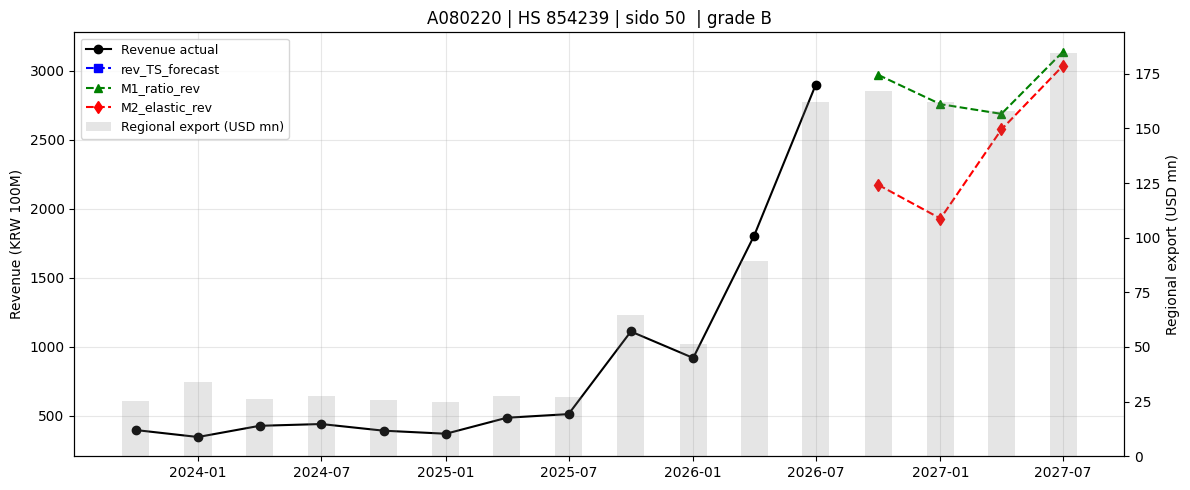

--- 제주반도체 분기 상세 (천원) ---


,revenue_actual,export_usd,export_src,M1_ratio_rev,M2_elastic_rev,rev_TS_forecast,ticker,company_name
2023Q3,3.951682e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2023Q4,3.446726e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q1,4.258980e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q2,4.387104e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q3,3.905089e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q4,3.683821e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q1,4.844025e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q2,5.106693e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q3,1.109511e+08,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q4,9.177224e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체


--- 제주반도체 연동성 검정 (lag별) ---


,lag,n,alpha,beta,t_hac,p_hac,r2,pearson,spearman,abs_p_minus_s,oos_rmse_ratio,n_oos,ticker,company_name,hs_code,sido_cd
0,0,23,0.025499,0.663066,2.744883,0.006053,0.192588,0.438848,0.623518,0.184670,1.467386,11,A080220,제주반도체,854239,50
1,1,23,0.231915,-0.017994,-0.027918,0.977727,0.000098,-0.009885,0.154150,0.164036,2.744471,11,A080220,제주반도체,854239,50
2,2,23,0.227568,0.002842,0.004924,0.996071,0.000002,0.001406,0.003953,0.002547,2.402526,11,A080220,제주반도체,854239,50


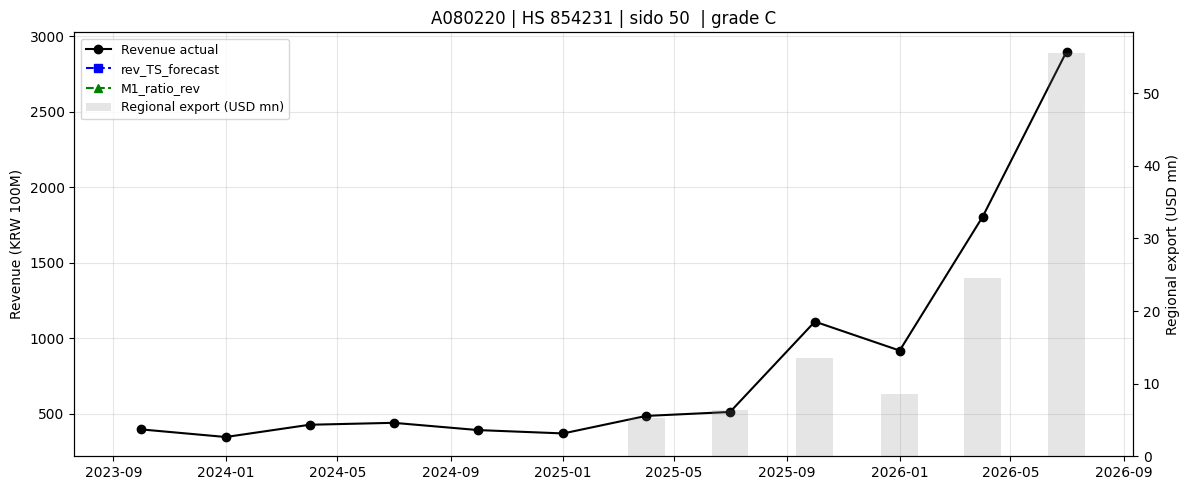

--- 제주반도체 분기 상세 (천원) ---


,revenue_actual,export_usd,export_src,M1_ratio_rev,rev_TS_forecast,ticker,company_name
2023Q3,3.951682e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2023Q4,3.446726e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q1,4.258980e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q2,4.387104e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q3,3.905089e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q4,3.683821e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q1,4.844025e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q2,5.106693e+07,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q3,1.109511e+08,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q4,9.177224e+07,NaN,NaN,NaN,NaN,A080220,제주반도체


--- 제주반도체 연동성 검정 (lag별) ---


,lag,n,grade_note,ticker,company_name,hs_code,sido_cd
0,0,5,insufficient_history,A080220,제주반도체,854231,50
1,1,4,insufficient_history,A080220,제주반도체,854231,50
2,2,3,insufficient_history,A080220,제주반도체,854231,50


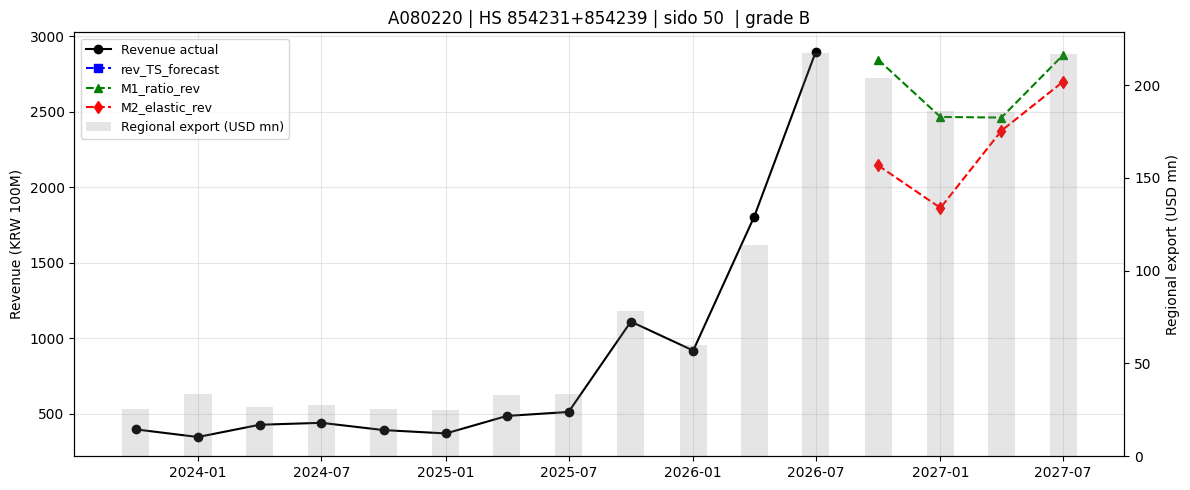

--- 제주반도체 분기 상세 (천원) ---


,revenue_actual,export_usd,export_src,M1_ratio_rev,M2_elastic_rev,rev_TS_forecast,ticker,company_name
2023Q3,3.951682e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2023Q4,3.446726e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q1,4.258980e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q2,4.387104e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q3,3.905089e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2024Q4,3.683821e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q1,4.844025e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q2,5.106693e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q3,1.109511e+08,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체
2025Q4,9.177224e+07,NaN,NaN,NaN,NaN,NaN,A080220,제주반도체


--- 제주반도체 연동성 검정 (lag별) ---


,lag,n,alpha,beta,t_hac,p_hac,r2,pearson,spearman,abs_p_minus_s,oos_rmse_ratio,n_oos,ticker,company_name,hs_code,sido_cd
0,0,23,-0.001637,0.668056,3.118651,0.001817,0.212354,0.460818,0.629447,0.168628,1.379660,11,A080220,제주반도체,854231+854239,50
1,1,23,0.208066,0.080216,0.131376,0.895478,0.002136,0.046221,0.198617,0.152396,2.775461,11,A080220,제주반도체,854231+854239,50
2,2,23,0.196221,0.157589,0.274464,0.783728,0.006723,0.081996,0.060277,0.021720,2.426166,11,A080220,제주반도체,854231+854239,50


[저장] C:\Users\82108\OneDrive\INVESTMENT\한국_지역별수출분석\202609\regional_export_revenue_20260928.xlsx


In [9]:
# =============================================================================
# PART 7-3. 기업 매출 연동 분석 + 결과 저장
# =============================================================================
fx_m = load_fx_monthly() if FX_ADJUST else None
results = [analyze_company(r, fx_m) for _, r in company_map.iterrows()]
# 같은 기업·지역에 HS가 2개 이상이면 합산 시계열 분석 추가
for (tk, nm, sd, sgg), grp in company_map.groupby(["ticker", "company_name", "sido_cd", "sgg_nm"]):
    if grp["hs_code"].nunique() >= 2:
        results.append(analyze_company_group(tk, nm, sd, sgg, sorted(grp["hs_code"].unique()), fx_m))

summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
pct_cols = [c for c in summary.columns if c.startswith("g_") or c in ("region_share_of_national_12m",)]
show = summary.copy()
for c in pct_cols:
    show[c] = (show[c] * 100).round(1)
print("[요약] g_* = 향후 4분기 합계 / 최근 4분기(TTM) 합계 - 1 (%)")
display(show)

for r in results:
    plot_company(r)
    if r.get("status") == "ok":
        print(f"--- {r['company_name']} 분기 상세 (천원) ---")
        display(r["_detail"])
        print(f"--- {r['company_name']} 연동성 검정 (lag별) ---")
        display(r["_linkage"])

out_xlsx = OUT_DIR / f"regional_export_revenue_{datetime.today():%Y%m%d}.xlsx"
with pd.ExcelWriter(out_xlsx) as xw:
    show.to_excel(xw, sheet_name="Summary", index=False)
    det = [r["_detail"].reset_index().rename(columns={"index": "quarter"}) for r in results if r.get("status") == "ok"]
    if det:
        d = pd.concat(det)
        d["quarter"] = d["quarter"].astype(str)
        d.to_excel(xw, sheet_name="Quarterly_Detail", index=False)
    lk = [r["_linkage"] for r in results if r.get("status") == "ok"]
    if lk:
        pd.concat(lk).to_excel(xw, sheet_name="Linkage", index=False)
    pd.DataFrame(collect_log).to_excel(xw, sheet_name="Collect_Log", index=False)
    pd.DataFrame(forecast_log).to_excel(xw, sheet_name="Forecast_Log", index=False)
    pd.DataFrame({
        "item": ["forecast_date", "fx_adjust", "implied_horizon_q", "lags", "oos_start", "ensemble"],
        "value": [FORECAST_DATE, FX_ADJUST and fx_m is not None, IMPLIED_HORIZON_Q, str(LAGS), OOS_START, ENSEMBLE_AGG],
    }).to_excel(xw, sheet_name="Meta", index=False)
print(f"[저장] {out_xlsx}")
